In [1]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Hardware Acceleration Enabled: Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("MPS not available. Falling back to CPU")

Hardware Acceleration Enabled: Using Apple Silicon GPU (MPS)


## 1. Transform and Load Data

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Train Set
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomAffine(degrees=15,
                            shear=15,
                            scale=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

training_set = datasets.ImageFolder(root='dataset/training_set', 
                                    transform=train_transforms)

train_loader = DataLoader(dataset=training_set, 
                          batch_size=32, 
                          shuffle=True)

# Test Set
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

test_set = datasets.ImageFolder(root='dataset/test_set', 
                                transform=test_transforms)

test_loader = DataLoader(dataset=test_set, 
                         batch_size=32, 
                         shuffle=False)

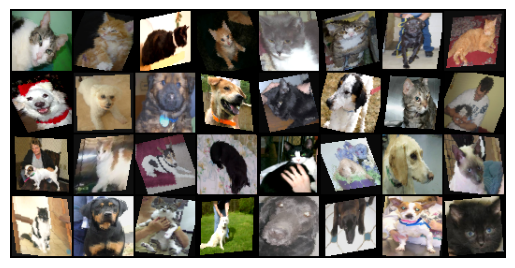

In [3]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def imgshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)
imgshow(torchvision.utils.make_grid(images, nrow=8))

## 2. Build the CNN Model

## CNN Spatial Dimension Calculations

Before defining the network architecture, we manually compute the feature map shapes across the convolutional and pooling layers to determine the precise input size for the fully connected (linear) layer.

### Formulas used:
- **Convolution (No Padding):** $$\text{Output Size} = \frac{\text{Input Size} - \text{Kernel Size}}{\text{Stride}} + 1$$
- **Max Pooling:** $$\text{Output Size} = \lfloor \frac{\text{Input Size} - \text{Pool Size}}{\text{Stride}} \rfloor + 1$$

### Step-by-Step Shape Tracking:
1. **Input Image:** Shape is `(3, 64, 64)` $\rightarrow$ `(Channels, Height, Width)`
2. **Step 1 - Convolution 1 (Filters=32, Kernel=3, Stride=1):** $$\text{Height/Width} = (64 - 3) + 1 = 62 \rightarrow \text{Shape: } (32, 62, 62)$$
3. **Step 2 - Max Pooling 1 (Pool=2, Stride=2):** $$\text{Height/Width} = \lfloor \frac{62 - 2}{2} \rfloor + 1 = 31 \rightarrow \text{Shape: } (32, 31, 31)$$
4. **Step 3 - Convolution 2 (Filters=32, Kernel=3, Stride=1):** $$\text{Height/Width} = (31 - 3) + 1 = 29 \rightarrow \text{Shape: } (32, 29, 29)$$
5. **Step 4 - Max Pooling 2 (Pool=2, Stride=2):** $$\text{Height/Width} = \lfloor \frac{29 - 2}{2} \rfloor + 1 = 14 \rightarrow \text{Shape: } (32, 14, 14)$$
6. **Step 5 - Flattening:** The total number of flattened features fed into the first Dense/Linear layer is:  
   $$\text{Total Features} = 32 \times 14 \times 14 = 6,272$$

In [4]:
import torch.nn as nn

class BinaryCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Step 1 & 2: First Convolutional Block ---
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- Step 3: Second Convolutional Block ---
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- Step 4: Flattening ---
        self.flatten = nn.Flatten()
        
        # --- Step 5: Full Connection (Dense 128) ---
        self.fc1 = nn.Linear(in_features=32 * 14 * 14, out_features=128)
        self.relu3 = nn.ReLU()

        # --- Step 6: Dropout Layer ---
        self.dropout = nn.Dropout(p=0.5)
        
        # --- Step 7: Output Layer (Dense 1) ---
        self.out = nn.Linear(in_features=128, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Flatten
        x = self.flatten(x)
        
        # Fully Connected
        x = self.fc1(x)
        x = self.relu3(x)
        
        # Dropout
        x = self.dropout(x)

        # Output
        x = self.out(x)
        x = self.sigmoid(x)
        
        return x
    
model = BinaryCNN().to(device)

from torchinfo import summary
summary(model, input_size=(32, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
BinaryCNN                                [32, 1]                   --
├─Conv2d: 1-1                            [32, 32, 62, 62]          896
├─ReLU: 1-2                              [32, 32, 62, 62]          --
├─MaxPool2d: 1-3                         [32, 32, 31, 31]          --
├─Conv2d: 1-4                            [32, 32, 29, 29]          9,248
├─ReLU: 1-5                              [32, 32, 29, 29]          --
├─MaxPool2d: 1-6                         [32, 32, 14, 14]          --
├─Flatten: 1-7                           [32, 6272]                --
├─Linear: 1-8                            [32, 128]                 802,944
├─ReLU: 1-9                              [32, 128]                 --
├─Dropout: 1-10                          [32, 128]                 --
├─Linear: 1-11                           [32, 1]                   129
├─Sigmoid: 1-12                          [32, 1]                   --
Total

## 3. Train the CNN

In [5]:
import torch.optim as optim

model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [6]:
epochs = 50

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

patience = 5
patience_counter = 0
best_test_loss = float('inf')


for epoch in range(epochs):
    # --- (Training Phase) ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = (outputs > 0.5).float()
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # --- (Validation/Test Phase) ---
    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().to(device).unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_test_loss += loss.item() * images.size(0)
            predictions = (outputs > 0.5).float()
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)
            
    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc*100:.2f}%")
    
    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered! No improvement for {patience} epochs.")
            break

model.load_state_dict(torch.load('best_model.pth'))
print("Best model weights loaded successfully.")

Epoch [1/50] -> Train Loss: 0.6854 | Train Acc: 54.52% | Test Loss: 0.6633 | Test Acc: 61.50%
Epoch [2/50] -> Train Loss: 0.6482 | Train Acc: 62.82% | Test Loss: 0.6135 | Test Acc: 67.20%
Epoch [3/50] -> Train Loss: 0.6214 | Train Acc: 65.79% | Test Loss: 0.5858 | Test Acc: 70.95%
Epoch [4/50] -> Train Loss: 0.6055 | Train Acc: 67.16% | Test Loss: 0.5917 | Test Acc: 69.25%
Epoch [5/50] -> Train Loss: 0.5843 | Train Acc: 68.91% | Test Loss: 0.5520 | Test Acc: 72.40%
Epoch [6/50] -> Train Loss: 0.5758 | Train Acc: 69.65% | Test Loss: 0.5377 | Test Acc: 73.60%
Epoch [7/50] -> Train Loss: 0.5634 | Train Acc: 70.30% | Test Loss: 0.5259 | Test Acc: 74.05%
Epoch [8/50] -> Train Loss: 0.5564 | Train Acc: 71.74% | Test Loss: 0.5586 | Test Acc: 71.55%
Epoch [9/50] -> Train Loss: 0.5497 | Train Acc: 72.01% | Test Loss: 0.5165 | Test Acc: 75.20%
Epoch [10/50] -> Train Loss: 0.5352 | Train Acc: 73.10% | Test Loss: 0.4937 | Test Acc: 76.65%
Epoch [11/50] -> Train Loss: 0.5424 | Train Acc: 72.88% | T

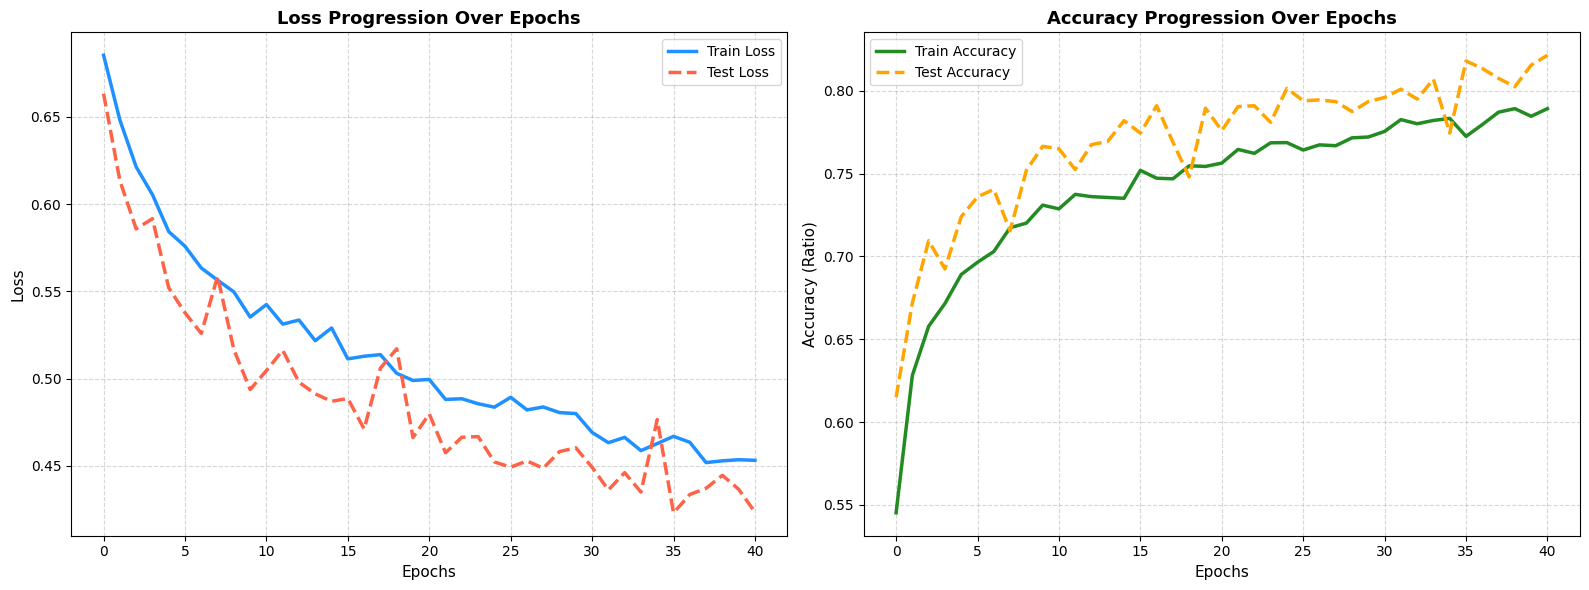

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
ax1.plot(history['train_loss'], color='dodgerblue', linewidth=2.5, label='Train Loss')
ax1.plot(history['test_loss'], color='tomato', linewidth=2.5, linestyle='--', label='Test Loss')
ax1.set_title('Loss Progression Over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10)

# --- Accuracy ---
ax2.plot(history['train_acc'], color='forestgreen', linewidth=2.5, label='Train Accuracy')
ax2.plot(history['test_acc'], color='orange', linewidth=2.5, linestyle='--', label='Test Accuracy')
ax2.set_title('Accuracy Progression Over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Accuracy (Ratio)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Prediction Probability: 0.9997
The image is classified as: dogs


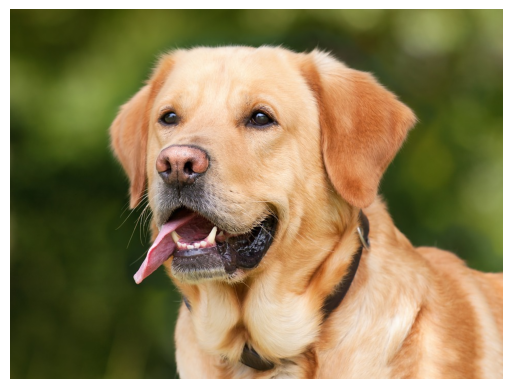

In [8]:
from PIL import Image

img_path = 'dataset/single_prediction/cat_or_dog_1.jpg'
raw_image = Image.open(img_path)

transformed_image = test_transforms(raw_image)

input_tensor = transformed_image.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    prediction_prob = output.item() 

idx_to_class = {v: k for k, v in training_set.class_to_idx.items()}

pred_idx = 1 if prediction_prob > 0.5 else 0
prediction = idx_to_class[pred_idx]

print(f"Prediction Probability: {prediction_prob:.4f}")
print(f"The image is classified as: {prediction}")

npimg = np.array(raw_image)
plt.imshow(npimg)
plt.axis("off")
plt.show()

Prediction Probability: 0.1733
The image is classified as: cats


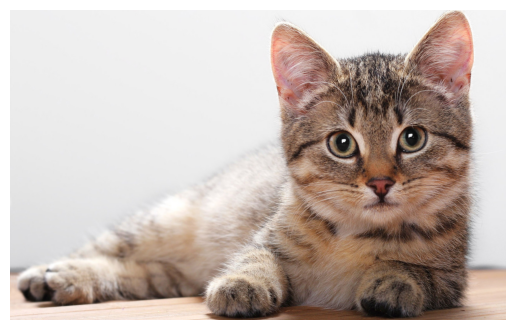

In [9]:
img_path = 'dataset/single_prediction/cat_or_dog_2.jpg'
raw_image = Image.open(img_path)

transformed_image = test_transforms(raw_image)

input_tensor = transformed_image.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    prediction_prob = output.item() 

idx_to_class = {v: k for k, v in training_set.class_to_idx.items()}

pred_idx = 1 if prediction_prob > 0.5 else 0
prediction = idx_to_class[pred_idx]

print(f"Prediction Probability: {prediction_prob:.4f}")
print(f"The image is classified as: {prediction}")

npimg = np.array(raw_image)
plt.imshow(npimg)
plt.axis("off")
plt.show()